In [1]:
# import necessary cmap packages to the read in gene signatures as a dataframe
import cmapPy.pandasGEXpress.GCToo as GCToo
from cmapPy.pandasGEXpress.parse import parse
import cmapPy.pandasGEXpress.subset_gctoo as sg

# import necessary preprocessing and data visualization tools
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# import modeling tools
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression

# Goal
The purpose of this project is to determine drugs treating the same indication (similar drugs) have similar effects on gene signature. The gene signatures were taken from the LINCS L1000 dataset, which is part of the [NIH LINCS L1000 project](https://lincsproject.org/LINCS/tools/workflows/find-the-best-place-to-obtain-the-lincs-l1000-data). This dataset contains gene expression profiles for thousands of perturbagens at a variety of time points, doses, and cell lines. What is unique about this dataset is that they directly measure the gene expression of 978 landmark genes and use a computational model to estimate the gene expression levels of over 10,000 other genes.

## Select only the 978 landmark genes and all the samples that had a high transcriptional response to drug compounds

In [2]:
# read gene info from gene_info metadata
file_path = "~/LINCS/ref_data/GSE70138_Broad_LINCS_gene_info_2017-03-06.txt"
gene_info = pd.read_csv(file_path, sep="\t", dtype=str)
gene_info.head()

,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


In [3]:
# select the ids of only the landmark genes
lm_gene_id = gene_info["pr_gene_id"][gene_info["pr_is_lm"] == "1"]

# check that I have the 978 landmark genes
print(len(lm_gene_id)) 

978


## Import the Drug Repurposing Hub indications for the drugs in the LINCS dataset

In [4]:
# import the collapsed version of the drug indications from the Drug Repurposing Hub
collapsed_drug_repo_ind = pd.read_csv('~/LINCS/ref_data/drug_ind/processed/collapsed_drug_repo_lincs_ind.txt')
collapsed_drug_repo_ind.head()

,pert_iname,indication
0,5-aminolevulinic-acid,"Keratosis, Actinic|Glioma"
1,L-citrulline,Hypertension|Erectile Dysfunction
2,SN-38,Colorectal Neoplasms
3,abacavir,HIV
4,abiraterone-acetate,Prostatic Neoplasms


In [5]:
# import the version of drug indications (one row for every indication of a drug)
drug_repo_ind = pd.read_csv('~/LINCS/ref_data/drug_ind/processed/LINCS_drug_repo_ind.txt')
drug_repo_ind.head()

,pert_iname,indication
0,5-aminolevulinic-acid,"Keratosis, Actinic"
1,5-aminolevulinic-acid,Glioma
2,abacavir,HIV
3,abiraterone-acetate,Prostatic Neoplasms
4,acarbose,Diabetes Mellitus


## Select the gene signatures ids of compounds of interest

#### *1. Import the sample information for all drug compounds*

In [6]:
# path to file
file_path = "~/LINCS/ref_data/GSE70138_Broad_LINCS_sig_info.txt"
# import relevant information from the file as a dataframe with index as the sample id (sig_id)
sig_info = pd.read_csv(file_path, sep="\t", dtype=str, index_col=0).drop(columns='distil_id')
# filter only the drug compounds
sig_info = sig_info[sig_info['pert_type'] == 'trt_cp']
# remove the pert_type column
sig_info.drop(columns='pert_type', inplace=True)
sig_info.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime
sig_id,,,,,
LJP005_A375_24H:A07,BRD-K76908866,CP-724714,A375,10.0 um,24 h
LJP005_A375_24H:A08,BRD-K76908866,CP-724714,A375,3.33 um,24 h
LJP005_A375_24H:A09,BRD-K76908866,CP-724714,A375,1.11 um,24 h
LJP005_A375_24H:A10,BRD-K76908866,CP-724714,A375,0.37 um,24 h
LJP005_A375_24H:A11,BRD-K76908866,CP-724714,A375,0.12 um,24 h


#### *2. Import the TAS scores*

In [7]:
# path to file
file_path = "~/LINCS/ref_data/GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt"
# import the tas scores from the file as a dataframe with sample id (sig_id) as the index 
tas_scores = pd.read_csv(file_path, usecols=['sig_id', 'tas'], sep='\t', index_col=0)
# remove all samples with a tas score < 0.2
tas_scores = tas_scores[tas_scores['tas'] > 0.2]

high_tas_sigs = pd.concat([sig_info, tas_scores], axis=1, sort=True)
high_tas_sigs = high_tas_sigs[high_tas_sigs['tas'].notna()]
high_tas_sigs.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,tas
LJP005_A375_24H:A07,BRD-K76908866,CP-724714,A375,10.0 um,24 h,0.442109
LJP005_A375_24H:A08,BRD-K76908866,CP-724714,A375,3.33 um,24 h,0.458614
LJP005_A375_24H:A10,BRD-K76908866,CP-724714,A375,0.37 um,24 h,0.229162
LJP005_A375_24H:A13,BRD-K85606544,neratinib,A375,10.0 um,24 h,0.397924
LJP005_A375_24H:A14,BRD-K85606544,neratinib,A375,3.33 um,24 h,0.449551


#### *3. Select only samples with indications available in the Drug Repurposing Hub*

In [8]:
# get a list of all compounds available in LINCS dataset
LINCS_cps = high_tas_sigs['pert_iname'].unique()
# get a list of all compounds available in drug repurposing hub
DRH_indications = collapsed_drug_repo_ind['pert_iname'].to_list()
# get all the compounds in LINCS dataset that have a known indication
cps_with_indications = set(DRH_indications) & set(LINCS_cps)
# filter only samples that have been treated with compounds with known indications
LINCS_sig_info = high_tas_sigs[high_tas_sigs['pert_iname'].isin(cps_with_indications)]
LINCS_sig_info.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,tas
LJP005_A375_24H:A13,BRD-K85606544,neratinib,A375,10.0 um,24 h,0.397924
LJP005_A375_24H:A14,BRD-K85606544,neratinib,A375,3.33 um,24 h,0.449551
LJP005_A375_24H:A15,BRD-K85606544,neratinib,A375,1.11 um,24 h,0.421605
LJP005_A375_24H:A16,BRD-K85606544,neratinib,A375,0.37 um,24 h,0.385313
LJP005_A375_24H:A17,BRD-K85606544,neratinib,A375,0.12 um,24 h,0.342939


In [9]:
LINCS_sig_info.shape

(12392, 6)

#### *4. Select samples of one cell line*

In [10]:
### function to select the dose with the highest tas score for samples treated by the same cell line and compound
def select_dose(cell_line_sigs):
    ## initialize an empty dataframe
    one_dose_sigs = pd.DataFrame()
    ## store all the unique compounds in the
    cps = cell_line_sigs['pert_iname'].unique()
    ## for each unique compound
    for cp in cps:
        # among the samples treated with that compound
        cp_sigs = cell_line_sigs[cell_line_sigs['pert_iname'] == cp]
        # add the sample with the highest tas score to the new dataframe
        one_dose_sigs = one_dose_sigs.append(cp_sigs.head(1))

    return one_dose_sigs

In [11]:
### function to select tas scores based on cell line at any tas cutoff
def select_samples(cell_line, tas_cutoff, sig_info):
    ## store all the drugs that have a tas score above the tas cutoff
    sigs_above_tas = sig_info[sig_info['tas'] > tas_cutoff]
    ## select all samples treated with the cell line of interest
    cell_line_sigs = sigs_above_tas[sigs_above_tas['cell_id'] == cell_line]
    ## sort the signatures from highest to lowest tas scores
    cell_line_sigs = cell_line_sigs.sort_values(by='tas', ascending=False)
    ## create a new dataframe containing the samples with the highest dose for each compound treated
    one_dose_sigs = select_dose(cell_line_sigs)
    
    return one_dose_sigs

In [12]:
# checking that functions work
one_dose_sigs = select_samples('MCF7', 0.6, LINCS_sig_info)
one_dose_sigs.head(10)

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,tas
REP.A020_MCF7_24H:G13,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,0.826145
REP.A010_MCF7_24H:L03,BRD-K14619660,altrenogest,MCF7,1.11 um,24 h,0.812819
REP.A015_MCF7_24H:E08,BRD-K56844688,epirubicin,MCF7,3.33 um,24 h,0.807126
REP.A020_MCF7_24H:L01,BRD-A45889380,mepacrine,MCF7,10.0 um,24 h,0.806568
REP.A010_MCF7_24H:I02,BRD-K13646352,midostaurin,MCF7,3.33 um,24 h,0.799386
REP.A025_MCF7_24H:L10,BRD-K76674262,homoharringtonine,MCF7,0.37 um,24 h,0.799271
REP.A015_MCF7_24H:P18,BRD-K61397605,romidepsin,MCF7,0.04 um,24 h,0.795148
REP.A023_MCF7_24H:O13,BRD-K72951360,valrubicin,MCF7,10.0 um,24 h,0.794730
REP.A024_MCF7_24H:N13,BRD-K78659596,ixazomib,MCF7,10.0 um,24 h,0.791817
REP.A008_MCF7_24H:O14,BRD-K89561498,SN-38,MCF7,3.33 um,24 h,0.787751


## Select gene signatures

In [13]:
# read the LINCS Level 5 dataset
file_path = "~/LINCS/ref_data/LINCS_dataset.gctx"

# select only the landmark gene of drug compounds of interest
gene_sigs = parse(file_path, rid=lm_gene_id, cid=one_dose_sigs.index)

In [14]:
# create a new GCTOO object with all the metadata for pair 
gene_sig_info = GCToo.GCToo(data_df=gene_sigs.data_df.copy(), 
                        row_metadata_df=gene_sigs.row_metadata_df.copy(), 
                        col_metadata_df=one_dose_sigs,
                        make_multiindex=True)
gene_sig_info.multi_index_df[:5]

pert_id,BRD-K21361524,BRD-K21680192,BRD-K43586850,BRD-K52020312,BRD-A68009927,BRD-K35960502,BRD-K89561498,BRD-K13646352,BRD-K14619660,BRD-K15179879,...,BRD-K92213669,BRD-K74717603,BRD-K75649340,BRD-K76674262,BRD-K92093830,BRD-K93779381,BRD-A94756469,BRD-K81418486,BRD-K17743125,BRD-A79768653
pert_iname,selinexor,mitoxantrone,lacidipine,metronidazole,daunorubicin,niclosamide,SN-38,midostaurin,altrenogest,carfilzomib,...,lomitapide,etravirine,tioguanine,homoharringtonine,doxorubicin,ingenol-mebutate,digoxin,vorinostat,belinostat,sirolimus
cell_id,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,...,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7
pert_idose,10.0 um,1.11 um,0.04 um,1.11 um,1.11 um,10.0 um,3.33 um,3.33 um,1.11 um,0.37 um,...,10.0 um,10.0 um,10.0 um,0.37 um,3.33 um,0.12 um,3.33 um,10.0 um,10.0 um,10.0 um
pert_itime,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,...,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h
tas,0.697827,0.681046,0.666125,0.641509,0.773276,0.720621,0.787751,0.799386,0.812819,0.763093,...,0.706904,0.642719,0.658646,0.799271,0.732233,0.624958,0.740309,0.707743,0.672252,0.642838
cid,REP.A004_MCF7_24H:E13,REP.A006_MCF7_24H:I15,REP.A007_MCF7_24H:B24,REP.A007_MCF7_24H:G21,REP.A008_MCF7_24H:A09,REP.A008_MCF7_24H:A13,REP.A008_MCF7_24H:O14,REP.A010_MCF7_24H:I02,REP.A010_MCF7_24H:L03,REP.A010_MCF7_24H:P04,...,REP.A025_MCF7_24H:C13,REP.A025_MCF7_24H:I07,REP.A025_MCF7_24H:J19,REP.A025_MCF7_24H:L10,REP.A026_MCF7_24H:L20,REP.A027_MCF7_24H:D23,REP.A027_MCF7_24H:E08,LJP008_MCF7_24H:A03,LJP008_MCF7_24H:L19,LJP009_MCF7_24H:B03
rid,,,,,,,,,,,,,,,,,,,,,
0,-1.379093,1.427287,-1.458264,-2.012370,1.262132,4.080800,-1.429472,0.760161,0.597249,-3.660214,...,3.849026,1.656333,-0.240879,-1.022303,-0.546943,0.930141,1.913610,0.170018,-2.323987,0.591201
1,0.603778,-0.022300,0.301619,-0.430541,1.424555,0.363052,2.850901,4.457971,3.194777,1.719087,...,0.266379,3.428610,-0.630775,-0.961700,0.574483,-0.352828,0.832979,-0.155810,0.514838,1.800988
2,-4.326672,-5.868003,-1.872412,-0.187459,-6.143412,0.810537,0.166969,1.211951,1.483787,-0.542654,...,0.026013,-0.276055,0.229357,-3.608992,-0.386431,-0.015385,1.021496,0.960363,-0.195015,3.163257


In [15]:
# replace the signature names with the drugs they were treated with
#gene_sig_info.data_df.columns = gene_sig_info.col_metadata_df['pert_iname']
# save MCF7 gene signatures to a csv file to perform WGCNA
#gene_sig_info.data_df.to_csv('MCF7_gene_sigs.csv', index=False)
# save metadata for these samples in a csv file
#gene_sig_info.col_metadata_df.to_csv('MCF7_sample_info.csv')

## Perform Pairwise Jaccard Similarity

In [16]:
### convert the gene signatures into ternary vectors for Jaccard Similarity
def create_ternary_vectors(gene_sig_info):
    ## initialize an empty dataframe to store the ternary vectors
    ternary_vectors = pd.DataFrame()
    ## store the gene signatures
    gene_sigs = gene_sig_info.data_df
    ## for each gene signature,
    for drug, gene_sig in gene_sigs.iteritems():
        # create the ternary vector
        ternary_vector = (abs(gene_sig) >= 2)*np.sign(gene_sig)
        # store the ternary vector in new dataframe
        ternary_vectors[drug] = ternary_vector
    return ternary_vectors

In [17]:
# check that the function works
ternary_vectors = create_ternary_vectors(gene_sig_info)
ternary_vectors.head()

,REP.A004_MCF7_24H:E13,REP.A006_MCF7_24H:I15,REP.A007_MCF7_24H:B24,REP.A007_MCF7_24H:G21,REP.A008_MCF7_24H:A09,REP.A008_MCF7_24H:A13,REP.A008_MCF7_24H:O14,REP.A010_MCF7_24H:I02,REP.A010_MCF7_24H:L03,REP.A010_MCF7_24H:P04,...,REP.A025_MCF7_24H:C13,REP.A025_MCF7_24H:I07,REP.A025_MCF7_24H:J19,REP.A025_MCF7_24H:L10,REP.A026_MCF7_24H:L20,REP.A027_MCF7_24H:D23,REP.A027_MCF7_24H:E08,LJP008_MCF7_24H:A03,LJP008_MCF7_24H:L19,LJP009_MCF7_24H:B03
rid,,,,,,,,,,,,,,,,,,,,,
780,-0.0,0.0,-0.0,-1.0,0.0,1.0,-0.0,0.0,0.0,-1.0,...,1.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-1.0,0.0
7849,0.0,-0.0,0.0,-0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0
6193,-1.0,-1.0,-0.0,-0.0,-1.0,0.0,0.0,0.0,0.0,-0.0,...,0.0,-0.0,0.0,-1.0,-0.0,-0.0,0.0,0.0,-0.0,1.0
23,0.0,0.0,-0.0,-0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,1.0,-0.0,-0.0,1.0,0.0,0.0,0.0
9552,-0.0,0.0,0.0,0.0,-1.0,0.0,0.0,-0.0,-0.0,0.0,...,0.0,0.0,0.0,-1.0,-0.0,-0.0,-0.0,0.0,-1.0,1.0


In [18]:
### function to calculate the jaccard index for a pair of drugs (using their ternary vectors)
def calc_jaccard_index(drug1_genes, drug2_genes):
    ## calculate the number of differentially expressed genes in either gene signature
    sum_union = sum(np.logical_or(drug1_genes, drug2_genes))
    ## if there are no differentially expressed genes in either gene signatures, return 0
    if sum_union == 0:
        return 0
    ## calculate the number of the same differentially expressed genes in both gene signatures
    sum_intersect = sum(np.logical_and(drug1_genes, drug2_genes))
    ## calculate the jaccard index
    jaccard_idx = sum_intersect / float(sum_union)
    return jaccard_idx

In [19]:
### function to perform pairwise jaccard similarity and spearman correlation
def pairwise_similarity(sig_info):
    ## 1. calculate the ternary vectors for jaccard similarity
    ternary_vectors = create_ternary_vectors(sig_info)
    ##
    
    ## 2. create an empty matrix to store jaccard indices
    num_cols = ternary_vectors.shape[1]
    jaccard_matrix = np.zeros((num_cols, num_cols))
    
    ## iterate over pairs of columns in the dataframe
    for row, drug1 in enumerate(ternary_vectors.columns):
        for col, drug2 in enumerate(ternary_vectors.columns):
            # compute jaccard index for each pair of columns
            jaccard_matrix[row, col] = calc_jaccard_index(ternary_vectors[drug1], ternary_vectors[drug2])
    
    # convert the jaccard matrix to a dataframe
    jaccard_df = pd.DataFrame(jaccard_matrix, columns=ternary_vectors.columns, index=ternary_vectors.columns)
    ##
    
    ## 3. perform pairwise spearman correlation 
    spearman_corrs = sig_info.data_df.corr(method='spearman')
    ##
    
    ## 4. create a new dataframe with all the similarity metrics
    # create a list with the names of the columns for the dataframe
    columns = ['drug1', 'drug1 tas', 'drug2', 'drug2 tas', 'spearman correlation', 'jaccard index']
    # create an empty dataframe to store the relevant information
    similarity_info = pd.DataFrame(columns=columns)
    # store the sig_ids of all the drugs
    all_cps = spearman_corrs.index
    
    # for each drug available,
    for sig_id1 in all_cps:
        # store the names and sig_ids of all the other drugs
        other_cps = all_cps[all_cps != sig_id1]
        # get the jaccard indices with all the other drugs
        jaccards = jaccard_df.loc[other_cps, sig_id1]
        # get the the spearman correlations with all the other drugs
        corrs = spearman_corrs.loc[other_cps, sig_id1]
        # get the name and tas the second drug
        cp2_info = sig_info.col_metadata_df.loc[other_cps, ['pert_iname', 'tas']]
        
        # create a dataframe containing the names of the other drugs, their tas, spearman correlation, and jaccard indices
        cp_sim_info = pd.concat([cp2_info, corrs, jaccards], axis=1).reset_index(drop=True)
        # rename the column names
        cp_sim_info.columns = ['drug2', 'drug2 tas', 'spearman correlation', 'jaccard index']
        # get the name of drug 1
        cp1_name = sig_info.col_metadata_df.loc[sig_id1, 'pert_iname']
        # add the name of drug 1
        cp_sim_info['drug1'] = [cp1_name]*len(cp_sim_info)
        # get the tas of drug1 
        cp1_tas = sig_info.col_metadata_df.loc[sig_id1, 'tas']
        # add the name of drug 1
        cp_sim_info['drug1 tas'] = [cp1_tas]*len(cp_sim_info)
        
        # add this data onto the running dataframe for all jaccard indices for all drugs
        similarity_info = similarity_info.append(cp_sim_info, ignore_index=True, sort=True)
    ##
    return similarity_info

In [20]:
# check that the function peforms as excepted
sim_info = pairwise_similarity(gene_sig_info)
sim_info.head(10)

,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation
0,selinexor,0.697827,mitoxantrone,0.681046,0.345972,0.470596
1,selinexor,0.697827,lacidipine,0.666125,0.344828,0.271337
2,selinexor,0.697827,metronidazole,0.641509,0.319569,0.301442
3,selinexor,0.697827,daunorubicin,0.773276,0.380261,0.448462
4,selinexor,0.697827,niclosamide,0.720621,0.336923,0.265733
5,selinexor,0.697827,SN-38,0.787751,0.395804,0.506269
6,selinexor,0.697827,midostaurin,0.799386,0.322793,0.178707
7,selinexor,0.697827,altrenogest,0.812819,0.335135,0.222497
8,selinexor,0.697827,carfilzomib,0.763093,0.352472,0.329610
9,selinexor,0.697827,penfluridol,0.659227,0.295681,0.205171


In [21]:
# replace the index and column names with the drug names
#jaccard_matrix.columns = gene_sig_info.col_metadata_df['pert_iname']
#jaccard_matrix.index = gene_sig_info.col_metadata_df['pert_iname']
# save as a csv for WGCNA
#jaccard_matrix.to_csv('MCF7_jaccard_similarity.csv')

## *Add the indications to the compound-indication Jaccard pairs*

In [22]:
### function to add a column determining whether drug2 can treat a known indication of drug1
def known_indication(row):
    ## get a list of indications of drug1
    drug1_indications = row['drug1 indication'].split('|')
    ## get the indication of drug2
    drug2_indication = row['drug2 indication']
    ## create a boolean whether drug2's indication is a known indication of drug1
    known_indication = drug2_indication in drug1_indications
    
    return known_indication

In [23]:
### function to add the indications of the drugs
def add_indications(sim_metrics, drug_inds, drug_ind):
    ## add the indications for the drug 1
    corrs_with_ind = pd.merge(sim_metrics, drug_inds[['pert_iname', 'indication']], left_on='drug1', right_on='pert_iname', how='left')
    ## add the indications for each of the drug 2
    corrs_with_ind = pd.merge(corrs_with_ind, drug_ind, left_on='drug2', right_on='pert_iname', how='left')
    
    ## remove the pert_iname columns
    corrs_with_ind.drop(columns=['pert_iname_x', 'pert_iname_y'], axis=1, inplace=True)
    ## rename the indication columns
    corrs_with_ind.rename(columns={'indication_x': 'drug1 indication', 'indication_y': 'drug2 indication'}, inplace=True)
    
    ## add a column determining if drug2 is a known indication of drug1
    corrs_with_ind['known indication'] = corrs_with_ind.apply(known_indication, axis=1)
    
    return corrs_with_ind

In [24]:
# checking that functions work
sim_with_ind = add_indications(sim_info, collapsed_drug_repo_ind, drug_repo_ind)
sim_with_ind.head(10)

,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,drug2 indication,known indication
0,selinexor,0.697827,mitoxantrone,0.681046,0.345972,0.470596,Multiple Myeloma,Prostatic Neoplasms,False
1,selinexor,0.697827,mitoxantrone,0.681046,0.345972,0.470596,Multiple Myeloma,"Leukemia, Myeloid, Acute",False
2,selinexor,0.697827,mitoxantrone,0.681046,0.345972,0.470596,Multiple Myeloma,Multiple Sclerosis,False
3,selinexor,0.697827,lacidipine,0.666125,0.344828,0.271337,Multiple Myeloma,Hypertension,False
4,selinexor,0.697827,metronidazole,0.641509,0.319569,0.301442,Multiple Myeloma,Rosacea,False
5,selinexor,0.697827,daunorubicin,0.773276,0.380261,0.448462,Multiple Myeloma,"Leukemia, Myeloid, Acute",False
6,selinexor,0.697827,daunorubicin,0.773276,0.380261,0.448462,Multiple Myeloma,Precursor Cell Lymphoblastic Leukemia-Lymphoma,False
7,selinexor,0.697827,niclosamide,0.720621,0.336923,0.265733,Multiple Myeloma,Cestoda,False
8,selinexor,0.697827,SN-38,0.787751,0.395804,0.506269,Multiple Myeloma,Colorectal Neoplasms,False
9,selinexor,0.697827,midostaurin,0.799386,0.322793,0.178707,Multiple Myeloma,"Leukemia, Myeloid, Acute",False


In [25]:
# number of compound-indication pairs
sim_with_ind.shape

(2440, 9)

In [26]:
### function to remove duplicate drug-indication pairs
def remove_duplicates(similarity_metric):
    ## sort the drug-indication pairs from highest to lowest spearman correlation
    by_drug2_tas = similarity_metric.sort_values(by='spearman correlation', ascending=False)
    
    ## for duplicate drug-indication pairs, keep only the one with the one with the highest spearman correlation
    unique_drug_indications = by_drug2_tas.drop_duplicates(subset=['drug1', 'drug2 indication'], keep='first')
    
    return unique_drug_indications

In [27]:
# checking that function works, should have only one unique drug-indication pair
unique_drug_indications = remove_duplicates(sim_with_ind)
unique_drug_indications.groupby(by=['drug1', 'drug2 indication']).size()

drug1                  drug2 indication                                
5-aminolevulinic-acid  Ancylostomatoidea                                   1
                       Anemia                                              1
                       Ascariasis                                          1
                       Atrial Fibrillation                                 1
                       Breast Neoplasms                                    1
                       Carcinoma, Non-Small-Cell Lung                      1
                       Cestoda                                             1
                       Colorectal Neoplasms                                1
                       Condylomata Acuminata                               1
                       Cystitis, Hemorrhagic                               1
                       Enterobius                                          1
                       Estrus                                              1
    

## Obtain Jaccard index and spearman correlations between all drug-indication pairs for each cell line

In [28]:
### function to automate the process of determining the jaccard indices for a cell line
def sims_by_cell_line(cell_line, tas_cutoff, sig_info, drug_inds, drug_ind):
    ### 1. select one drug per sample for that cell line with a TAS > 0.2 and known indications
    samples2compare = select_samples(cell_line, tas_cutoff, sig_info)
    ###

    ### 2. select the gene signatures
    # read the LINCS Level 5 dataset
    file_path = "~/LINCS/ref_data/LINCS_dataset.gctx"

    # select only the landmark gene of drug compounds of interest
    gene_sigs = parse(file_path, rid=lm_gene_id, cid=samples2compare.index)

    # create a new GCTOO object with all the metadata for pair 
    gene_sig_info = GCToo.GCToo(data_df=gene_sigs.data_df.copy(), 
                            row_metadata_df=gene_sigs.row_metadata_df.copy(), 
                            col_metadata_df=samples2compare,
                            make_multiindex=True)
    ###

    ### 3. perform a pairwise jaccard similarity and spearman correlation
    sim_info = pairwise_similarity(gene_sig_info)
    ###
    
    ### 4. add the indications of the compound-indication pairs
    sim_with_indications = add_indications(sim_info, drug_inds, drug_ind)
    ###
    
    ### 5. remove duplicate drug-indication pairs and keep only the pair with the highest tas for drug 2
    unique_drug_indications = remove_duplicates(sim_with_indications)
    ###
    
    return unique_drug_indications

In [29]:
### function to automate process of determining the jaccard similarity and spearman correlations for various tas cutoffs of a cell line
def across_tas(cell_line, sig_info, drug_inds, drug_ind):
    ## initalize an empty dictionary to store the jaccard indices and spearman correlations using each tas cutoff
    sim_metrics = {}
    ## and each tas cutoff in that cell line,
    for tas_cutoff in tas_cutoffs:
        # generate the available jaccard index and spearman correlation pairs for all samples with a TAS > tas cutoff
        tas_sims = sims_by_cell_line(cell_line, tas_cutoff, sig_info, drug_inds, drug_ind)
        # add the dataset to the running dictionary
        sim_metrics[tas_cutoff] = tas_sims

    return sim_metrics

#### *a. MCF7 cell line*

In [30]:
# list of tas cutoff to use to perform analysis
tas_cutoffs = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

# get the summarized table containing all jaccard indices and spearman correlations for MCF7
MCF7_sim_metrics = across_tas('MCF7', LINCS_sig_info, collapsed_drug_repo_ind, drug_repo_ind)
MCF7_sim_metrics[0.6].head()

,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,drug2 indication,known indication
427,midostaurin,0.799386,altrenogest,0.812819,0.718935,0.908978,"Leukemia, Myeloid, Acute",Estrus,False
487,altrenogest,0.812819,midostaurin,0.799386,0.718935,0.908978,Estrus,"Leukemia, Myeloid, Acute",False
1110,ixazomib-citrate,0.747696,ixazomib,0.791817,0.670400,0.889649,Multiple Myeloma,Multiple Myeloma,True
1817,ixazomib,0.791817,ixazomib-citrate,0.747696,0.670400,0.889649,Multiple Myeloma,Multiple Myeloma,True
563,carfilzomib,0.763093,ixazomib-citrate,0.747696,0.597246,0.839315,Multiple Myeloma,Multiple Myeloma,True


#### *b. A375 cell line*

In [31]:
# get the summarized table containing all jaccard indices and spearman correlations for A375
A375_sim_metrics = across_tas('A375', LINCS_sig_info, collapsed_drug_repo_ind, drug_repo_ind)
A375_sim_metrics[0.6].head()

,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,drug2 indication,known indication
1070,lacidipine,0.816734,metronidazole,0.823728,0.760163,0.928048,Hypertension,Rosacea,False
1176,metronidazole,0.823728,lacidipine,0.816734,0.760163,0.928048,Rosacea,Hypertension,False
1495,SN-38,0.830311,daunorubicin,0.826015,0.709593,0.891780,Colorectal Neoplasms,"Leukemia, Myeloid, Acute",False
1285,daunorubicin,0.826015,SN-38,0.830311,0.709593,0.891780,"Leukemia, Myeloid, Acute|Precursor Cell Lympho...",Colorectal Neoplasms,False
1496,SN-38,0.830311,daunorubicin,0.826015,0.709593,0.891780,Colorectal Neoplasms,Precursor Cell Lymphoblastic Leukemia-Lymphoma,False


#### *c. PC3 cell line*

In [32]:
# get the summarized table containing all jaccard indices and spearman correlations for PC3
PC3_sim_metrics = across_tas('PC3', LINCS_sig_info, collapsed_drug_repo_ind, drug_repo_ind)
PC3_sim_metrics[0.6].head()

,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,drug2 indication,known indication
1768,ixazomib,0.781104,floxuridine,0.669218,0.597222,0.844395,Multiple Myeloma,Colorectal Neoplasms,False
1708,floxuridine,0.669218,ixazomib,0.781104,0.597222,0.844395,Colorectal Neoplasms,Multiple Myeloma,False
732,midostaurin,0.801405,altrenogest,0.792462,0.698630,0.842939,"Leukemia, Myeloid, Acute",Estrus,False
792,altrenogest,0.792462,midostaurin,0.801405,0.698630,0.842939,Estrus,"Leukemia, Myeloid, Acute",False
862,carfilzomib,0.711043,ixazomib-citrate,0.752297,0.609881,0.834510,Multiple Myeloma,Multiple Myeloma,True


## Logistic Regression Model to Determine if Each Drug Treats Indication

In [33]:
### function to create a logistic regression model for each cell line
def gen_lr_model(sim_metrics):
    ## initialize a dataframe to store the model predictions
    tas_predictions = sim_metrics.copy()
    ## define inputs into the model are: drug1 tas, drug2 tas, jaccard index, and spearman correlation for cell line
    X = tas_predictions[['drug1 tas', 'drug2 tas', 'jaccard index', 'spearman correlation']]
    ## define outputs of the model as whether drug2 treats a known indication of drug1 (0=no, 1=yes)
    y = tas_predictions['known indication'].astype(int)
    ## train logistic regression model based on labelled input and outputs
    model = LogisticRegression(class_weight='balanced').fit(X, y)

    # get the predictions from the model
    tas_predictions['model prediction probabilities'] = model.predict_proba(X)[:, 1]
    tas_predictions['model predictions'] = model.predict(X)
    
    return tas_predictions, model

In [34]:
### initialize empty dictionaries to store the predictions for each cell line
MCF7_predictions = {}
A375_predictions = {}
PC3_predictions = {}

### initialize empty dictionaries to store the models for each cell line
MCF7_models = {}
A375_models = {}
PC3_models = {}

### for each tas cutoff,
for tas_cutoff in tas_cutoffs:
    ### store the model prediction probabilities at that tas cutoff
    MCF7_predictions[tas_cutoff], MCF7_models[tas_cutoff] = gen_lr_model(MCF7_sim_metrics[tas_cutoff])
    A375_predictions[tas_cutoff], A375_models[tas_cutoff] = gen_lr_model(A375_sim_metrics[tas_cutoff])
    PC3_predictions[tas_cutoff], PC3_models[tas_cutoff] = gen_lr_model(PC3_sim_metrics[tas_cutoff])

MCF7_predictions[0.6].head(10)

/home/katie_huang_student_uml_edu/.conda/envs/CMapPy_env/lib/python2.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,drug2 indication,known indication,model prediction probabilities,model predictions
427,midostaurin,0.799386,altrenogest,0.812819,0.718935,0.908978,"Leukemia, Myeloid, Acute",Estrus,False,0.915850,1
487,altrenogest,0.812819,midostaurin,0.799386,0.718935,0.908978,Estrus,"Leukemia, Myeloid, Acute",False,0.914238,1
1110,ixazomib-citrate,0.747696,ixazomib,0.791817,0.670400,0.889649,Multiple Myeloma,Multiple Myeloma,True,0.914680,1
1817,ixazomib,0.791817,ixazomib-citrate,0.747696,0.670400,0.889649,Multiple Myeloma,Multiple Myeloma,True,0.909213,1
563,carfilzomib,0.763093,ixazomib-citrate,0.747696,0.597246,0.839315,Multiple Myeloma,Multiple Myeloma,True,0.889652,1
1076,ixazomib-citrate,0.747696,metronidazole,0.641509,0.520522,0.818885,Multiple Myeloma,Rosacea,False,0.882301,1
204,metronidazole,0.641509,ixazomib-citrate,0.747696,0.520522,0.818885,Rosacea,Multiple Myeloma,False,0.898285,1
1289,bortezomib,0.826145,ixazomib,0.791817,0.605891,0.806020,"Lymphoma, Mantle-Cell|Multiple Myeloma",Multiple Myeloma,True,0.858913,1
1820,ixazomib,0.791817,bortezomib,0.826145,0.605891,0.806020,Multiple Myeloma,"Lymphoma, Mantle-Cell",False,0.865213,1
637,penfluridol,0.659227,lomitapide,0.706904,0.546000,0.801042,Schizophrenia,Hypercholesterolemia,False,0.887023,1


In [35]:
# store the results for each individual cell line models across all TAS cutoffs in a dictionary
all_train_pred = {'MCF7': MCF7_predictions,
                   'A375': A375_predictions,
                   'PC3': PC3_predictions}

# store individual cell line models across all TAS cutoffs in a dictionary
all_models = {'MCF7': MCF7_models,
              'A375': A375_models,
              'PC3': PC3_models}

## External Validation

#### *1. Import the clinical trials indications of drugs*

In [41]:
# import all the indications associated with a drug in the LINCS dataset
collapsed_clin_inds = pd.read_csv('~/LINCS/ref_data/drug_ind/processed/collapsed_LINCS_clinical_ind (AACT).txt')
collapsed_clin_inds.head()

,pert_iname,indication
0,2-methoxyestradiol,"Multiple Myeloma|Neoplasms, Plasma Cell|Gliobl..."
1,"3,3'-diindolylmethane",Breast Neoplasms|Prostatic Neoplasms|Thyroid D...
2,5-aminolevulinic-acid,"Bowen's Disease|Keratosis, Actinic|Keratosis|B..."
3,ACY-1215,"Multiple Myeloma|Neoplasms, Plasma Cell|Fallop..."
4,ASA-404,Neoplasms|Lung Neoplasms|Small Cell Lung Carci...


In [42]:
# import the clinical indications of drugs used in the LINCS dataset 
clin_ind = pd.read_csv('~/LINCS/ref_data/drug_ind/processed/LINCS_clinical_ind (AACT).txt')
clin_ind.head()

,pert_iname,indication,drugbank_id
0,2-methoxyestradiol,Multiple Myeloma,DB02342
1,2-methoxyestradiol,"Neoplasms, Plasma Cell",DB02342
2,2-methoxyestradiol,Glioblastoma,DB02342
3,2-methoxyestradiol,Carcinoid Tumor,DB02342
4,2-methoxyestradiol,Prostatic Neoplasms,DB02342


In [43]:
# get a list of all compounds available from the clinical trials dataset
clin_cps = collapsed_clin_inds['pert_iname']
# get all the compounds in LINCS dataset that have a known indication
cps_with_indications = set(clin_cps) & set(LINCS_cps)
# filter only samples that have been treated with compounds with known indications
clin_sig_info = high_tas_sigs[high_tas_sigs['pert_iname'].isin(cps_with_indications)]
clin_sig_info.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,tas
LJP005_A375_24H:A19,BRD-K78431006,crizotinib,A375,10.0 um,24 h,0.409499
LJP005_A375_24H:A20,BRD-K78431006,crizotinib,A375,3.33 um,24 h,0.371808
LJP005_A375_24H:A21,BRD-K78431006,crizotinib,A375,1.11 um,24 h,0.275981
LJP005_A375_24H:A23,BRD-K78431006,crizotinib,A375,0.12 um,24 h,0.232353
LJP005_A375_24H:C13,BRD-K56343971,vemurafenib,A375,10.0 um,24 h,0.639785


#### *2. Generate the validation datasets for drugs in clinical trials dataset*

##### *a. MCF7 spearman correlations*

In [44]:
# get the summarized table containing all spearman correlations and jaccard index for MCF7
MCF7_val_corrs = across_tas('MCF7', clin_sig_info, collapsed_clin_inds, clin_ind)
MCF7_val_corrs[0.6].head()

,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,drug2 indication,drugbank_id,known indication
50878,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,POEMS Syndrome,DB09570,False
50904,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,"Carcinoma, Renal Cell",DB09570,False
50911,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,"Multiple Sclerosis, Chronic Progressive",DB09570,False
50910,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,"Multiple Sclerosis, Relapsing-Remitting",DB09570,False
50909,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,Multiple Sclerosis,DB09570,False


##### *b. A375 spearman correlations*

In [45]:
# get the summarized table containing all spearman correlations and jaccard index for A375
A375_val_corrs = across_tas('A375', clin_sig_info, collapsed_clin_inds, clin_ind)
A375_val_corrs[0.6].head()

,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,drug2 indication,drugbank_id,known indication
38693,lacidipine,0.816734,metronidazole,0.823728,0.760163,0.928048,"Hypertension|Angina Pectoris|Angina, Stable","Colitis, Ulcerative",DB00916,False
38791,lacidipine,0.816734,metronidazole,0.823728,0.760163,0.928048,"Hypertension|Angina Pectoris|Angina, Stable",Uterine Cervical Neoplasms,DB00916,False
38783,lacidipine,0.816734,metronidazole,0.823728,0.760163,0.928048,"Hypertension|Angina Pectoris|Angina, Stable","Pneumonia, Bacterial",DB00916,False
38784,lacidipine,0.816734,metronidazole,0.823728,0.760163,0.928048,"Hypertension|Angina Pectoris|Angina, Stable",Cross Infection,DB00916,False
38786,lacidipine,0.816734,metronidazole,0.823728,0.760163,0.928048,"Hypertension|Angina Pectoris|Angina, Stable",Systemic Inflammatory Response Syndrome,DB00916,False


##### *c. PC3 spearman correlations*

In [46]:
# get the summarized table containing all spearman correlations and jaccard index for PC3
PC3_val_corrs = across_tas('PC3', clin_sig_info, collapsed_clin_inds, clin_ind)
PC3_val_corrs[0.6].head()

,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,drug2 indication,drugbank_id,known indication
53097,lonidamine,0.766502,ixazomib,0.781104,0.748322,0.918513,Prostatic Hyperplasia|Hyperplasia,Neoplasms,DB09570,False
53120,lonidamine,0.766502,ixazomib,0.781104,0.748322,0.918513,Prostatic Hyperplasia|Hyperplasia,Burkitt Lymphoma,DB09570,False
53105,lonidamine,0.766502,ixazomib,0.781104,0.748322,0.918513,Prostatic Hyperplasia|Hyperplasia,"Leukemia, Erythroblastic, Acute",DB09570,False
53104,lonidamine,0.766502,ixazomib,0.781104,0.748322,0.918513,Prostatic Hyperplasia|Hyperplasia,"Leukemia, Megakaryoblastic, Acute",DB09570,False
53103,lonidamine,0.766502,ixazomib,0.781104,0.748322,0.918513,Prostatic Hyperplasia|Hyperplasia,"Leukemia, Myelomonocytic, Acute",DB09570,False


In [47]:
# store all the spearman correlations and jaccard index in a dictionary
all_val_pred = {'MCF7': MCF7_val_corrs,
                 'A375': A375_val_corrs,
                 'PC3': PC3_val_corrs}

#### *3. Generate predictions for drug from the individual cell line models from data from Drug Repurposing Hub*

In [48]:
### for each cell line
for cell_line in all_val_pred:
    ## iterate through each tas cutoff based validation dataset
    for tas_cutoff in tas_cutoffs:
        # store the TAS and spearman correlations of validation dataset for that cell line
        val_corrs = all_val_pred[cell_line][tas_cutoff]
        # store the model to use to make predictions
        lr_model = all_models[cell_line][tas_cutoff]
        # store the inputs to put into the model
        X = val_corrs[['drug1 tas', 'drug1 tas', 'jaccard index', 'spearman correlation']]
        # add a column containing the predictions for that model
        val_corrs['model prediction probabilities'] = lr_model.predict_proba(X)[:, 1]

In [49]:
# check that predictions were added to the validation datasets
all_val_pred['MCF7'][0.6].head()

,drug1,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,drug2 indication,drugbank_id,known indication,model prediction probabilities
50878,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,POEMS Syndrome,DB09570,False,0.915945
50904,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,"Carcinoma, Renal Cell",DB09570,False,0.915945
50911,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,"Multiple Sclerosis, Chronic Progressive",DB09570,False,0.915945
50910,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,"Multiple Sclerosis, Relapsing-Remitting",DB09570,False,0.915945
50909,lonidamine,0.763669,ixazomib,0.791817,0.712025,0.897118,Prostatic Hyperplasia|Hyperplasia,Multiple Sclerosis,DB09570,False,0.915945


## Combined models

#### *a. Select all the drug-indication pairs shared in all cell lines (intersection)*

In [50]:
### function to generate dataset for intersection combined model
def shared_predictions(all_train_pred):
    ## initialize an empty dictionary containing all model predictions shared across all cell lines
    intersected_corrs = {}
    
    ## store the name of each individual model name and their predictions
    MCF7 = all_train_pred['MCF7']
    A375 = all_train_pred['A375']
    PC3 = all_train_pred['PC3']
    
    ## for each tas cutoff,
    for tas_cutoff in tas_cutoffs:
        # create a new dataframe containing the drug-indication pairs across both MCF7 and A375
        MFC7_A375 = pd.merge(MCF7[tas_cutoff], A375[tas_cutoff], on=['drug1', 'drug2 indication'], how='inner')

        # create a new dataframe containing the drug-indication pairs across all cell lines
        all_shared = pd.merge(MFC7_A375, PC3[tas_cutoff], on=['drug1', 'drug2 indication'], how='inner')

        # create dictionary for new labels for some columns
        new_col_names = {'model prediction probabilities_x': 'MCF7 model probabilities',
                         'model prediction probabilities_y': 'A375 model probabilities',
                         'model prediction probabilities': 'PC3 model probabilities'}
        # rename columns
        all_shared.rename(columns=new_col_names, inplace=True)

        # add another column containing the average probabilities across all cell lines
        all_shared['average probability'] = all_shared.loc[:, ['MCF7 model probabilities', 'A375 model probabilities', 'PC3 model probabilities']].mean(axis=1)

        # store this in a dictionary with that tas cutoff
        intersected_corrs[tas_cutoff] = all_shared

    return intersected_corrs

In [51]:
# generate the training data for intersection logistic regression model 
train_intersected_corrs = shared_predictions(all_train_pred)
train_intersected_corrs[0.6].head()

,drug1,drug1 tas_x,drug2_x,drug2 tas_x,jaccard index_x,spearman correlation_x,drug1 indication_x,drug2 indication,known indication_x,MCF7 model probabilities,...,drug1 tas,drug2,drug2 tas,jaccard index,spearman correlation,drug1 indication,known indication,PC3 model probabilities,model predictions,average probability
0,midostaurin,0.799386,altrenogest,0.812819,0.718935,0.908978,"Leukemia, Myeloid, Acute",Estrus,False,0.915850,...,0.801405,altrenogest,0.792462,0.698630,0.842939,"Leukemia, Myeloid, Acute",False,0.841266,1,0.856993
1,altrenogest,0.812819,midostaurin,0.799386,0.718935,0.908978,Estrus,"Leukemia, Myeloid, Acute",False,0.914238,...,0.792462,midostaurin,0.801405,0.698630,0.842939,Estrus,False,0.844907,1,0.859867
2,ixazomib-citrate,0.747696,ixazomib,0.791817,0.670400,0.889649,Multiple Myeloma,Multiple Myeloma,True,0.914680,...,0.752297,carfilzomib,0.711043,0.609881,0.834510,Multiple Myeloma,True,0.822736,1,0.821461
3,ixazomib,0.791817,ixazomib-citrate,0.747696,0.670400,0.889649,Multiple Myeloma,Multiple Myeloma,True,0.909213,...,0.781104,ixazomib-citrate,0.752297,0.607362,0.804777,Multiple Myeloma,True,0.816965,1,0.829670
4,carfilzomib,0.763093,ixazomib-citrate,0.747696,0.597246,0.839315,Multiple Myeloma,Multiple Myeloma,True,0.889652,...,0.711043,ixazomib-citrate,0.752297,0.609881,0.834510,Multiple Myeloma,True,0.840499,1,0.787208


#### *b. Select all the drug-indication pairs shared across all cell lines*

In [52]:
### function to generate dataset for union combined models across all TAS cutoffs
def gen_union_corrs(all_train_pred):
    ### initalize an empty dictionary to store the combined datasets
    union_corrs = {}
    
    ### store the individual cell line model predictions
    MCF7 = all_train_pred['MCF7']
    A375 = all_train_pred['A375']
    PC3 = all_train_pred['PC3']
    
    ### for each tas cutoffs performed
    for tas_cutoff in tas_cutoffs:
        ## get the correlations above tas cutoff and add a column containing the cell line the drug-indication pair came from
        MCF7_corrs = MCF7[tas_cutoff][['drug1', 'drug2 indication', 'known indication', 'model prediction probabilities']]
        A375_corrs = A375[tas_cutoff][['drug1', 'drug2 indication', 'known indication', 'model prediction probabilities']]
        PC3_corrs = PC3[tas_cutoff][['drug1', 'drug2 indication', 'known indication', 'model prediction probabilities']]

        # create a new dataframe containing the drug-indication pairs across both MCF7 and A375
        MFC7_A375 = MCF7_corrs.merge(A375_corrs, on=['drug1', 'drug2 indication'], how='outer')

        # create a new dataframe containing the drug-indication pairs across all cell lines
        all_shared = pd.merge(MFC7_A375, PC3_corrs, on=['drug1', 'drug2 indication'], how='outer')
        
        # combine known indications into one column
        all_shared['known indication'] = all_shared['known indication'] | all_shared['known indication_x'] | all_shared['known indication_y']
        all_shared.drop(columns=['known indication_x', 'known indication_y'], axis=1, inplace=True)

        ## rename the columns
        all_shared = all_shared.rename(columns={'model prediction probabilities_x': 'MCF7',
                                             'model prediction probabilities_y': 'A375',
                                             'model prediction probabilities': 'PC3'})
        ## add this to the running dictionary for all tas cutoffs
        union_corrs[tas_cutoff] = all_shared
        
    return union_corrs

In [53]:
# generate the training data for the union models
train_union_corrs = gen_union_corrs(all_train_pred)
train_union_corrs[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3
0,midostaurin,Estrus,0.915850,0.813861,False,0.841266
1,altrenogest,"Leukemia, Myeloid, Acute",0.914238,0.820456,False,0.844907
2,ixazomib-citrate,Multiple Myeloma,0.914680,0.726967,True,0.822736
3,ixazomib,Multiple Myeloma,0.909213,0.762831,True,0.816965
4,carfilzomib,Multiple Myeloma,0.889652,0.631472,True,0.840499


In [54]:
# generate the validation data for the union models
val_union_corrs = gen_union_corrs(all_val_pred)
val_union_corrs[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3
0,lonidamine,POEMS Syndrome,0.915945,0.842818,False,0.868023
1,lonidamine,"Carcinoma, Renal Cell",0.915945,0.842818,False,0.868023
2,lonidamine,"Multiple Sclerosis, Chronic Progressive",0.915945,0.842818,False,0.868023
3,lonidamine,"Multiple Sclerosis, Relapsing-Remitting",0.915945,0.842818,False,0.868023
4,lonidamine,Multiple Sclerosis,0.915945,0.842818,False,0.868023


In [55]:
### function to get the weighted average of the combined predictions
def weighted_average(combined_predictions, weights, tas_cutoff):
    ## make a copy of the all the predictions
    weighted_predictions = combined_predictions[tas_cutoff].copy()
    ## multiply the original predictions by the specified weight for that cell line
    weighted_predictions['MCF7'] = weighted_predictions['MCF7']*weights['MCF7']
    weighted_predictions['A375'] = weighted_predictions['A375']*weights['A375']
    weighted_predictions['PC3'] = weighted_predictions['PC3']*weights['PC3']
    ## find the the sum of the weights of cell lines available (denominator)
    weighted_predictions['total_weights'] = weighted_predictions.apply(lambda row: sum(weights[cell_line] for cell_line in weights if not np.isnan(row[cell_line])), axis=1)
    ## add a column containing the weighted average across the cell lines
    weighted_predictions['model prediction probabilities'] = weighted_predictions[['MCF7', 'A375', 'PC3']].sum(axis=1)/weighted_predictions['total_weights']
    
    return weighted_predictions

In [56]:
### function to generate the weighted average of the combined predictions for union model
def gen_unweighted_union(union_corrs):
    ## initialize a dictionary to store the weighted predictions the dataset for each tas cutoff used
    ensemble_probs = {}
    ## for each tas cutoff performed
    for tas_cutoff in tas_cutoffs:
        # define the weights
        weights = {'MCF7': 1,
                   'A375': 1,
                   'PC3': 1}
        
        # get the weighted average of predicted probabilities across all cell lines
        weighted_predictions = weighted_average(union_corrs, weights, tas_cutoff)
        # store the weighted predictions in the running dictionary for all tas cutoffs
        ensemble_probs[tas_cutoff] = weighted_predictions

    return ensemble_probs

In [57]:
# generate the unweighted union model predictions for the training dataset (Drug Repurposing Hub)
train_unweighted_union = gen_unweighted_union(train_union_corrs)
train_unweighted_union[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3,total_weights,model prediction probabilities
0,midostaurin,Estrus,0.915850,0.813861,False,0.841266,3,0.856993
1,altrenogest,"Leukemia, Myeloid, Acute",0.914238,0.820456,False,0.844907,3,0.859867
2,ixazomib-citrate,Multiple Myeloma,0.914680,0.726967,True,0.822736,3,0.821461
3,ixazomib,Multiple Myeloma,0.909213,0.762831,True,0.816965,3,0.829670
4,carfilzomib,Multiple Myeloma,0.889652,0.631472,True,0.840499,3,0.787208


In [58]:
# generate the unweighted union model predictions for the validation dataset (clin)
val_unweighted_union = gen_unweighted_union(val_union_corrs)
val_unweighted_union[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3,total_weights,model prediction probabilities
0,lonidamine,POEMS Syndrome,0.915945,0.842818,False,0.868023,3,0.875596
1,lonidamine,"Carcinoma, Renal Cell",0.915945,0.842818,False,0.868023,3,0.875596
2,lonidamine,"Multiple Sclerosis, Chronic Progressive",0.915945,0.842818,False,0.868023,3,0.875596
3,lonidamine,"Multiple Sclerosis, Relapsing-Remitting",0.915945,0.842818,False,0.868023,3,0.875596
4,lonidamine,Multiple Sclerosis,0.915945,0.842818,False,0.868023,3,0.875596


## Create the union ensemble model taking the weighted average using another logistic regression model

In [59]:
### function to determine the weights to apply to each individual cell line for data at one tas cutoff
def determine_weights(intersected_corrs, tas_cutoff):
    # define the input to the logistic regression model
    X = intersected_corrs[tas_cutoff].loc[:, ['MCF7 model probabilities', 'A375 model probabilities', 'PC3 model probabilities']]
    # define the output as whether they are known indications
    y = intersected_corrs[tas_cutoff]['known indication'].astype(int)
    # train a logistic regression model to determine the weights to apply to each cell line model
    combined_lr_model = LogisticRegression().fit(X, y)
    # store the weights determined for each cell line
    tas_weights = {'MCF7': combined_lr_model.coef_[0][0],
                   'A375': combined_lr_model.coef_[0][1],
                   'PC3': combined_lr_model.coef_[0][2]}
    return tas_weights, combined_lr_model

In [60]:
### function to generate the weighted average of the combined predictions for union model
def union_ensemble(intersected_corrs, union_corrs):
    ## initialize an dataframe to store the relevant information
    cell_line_weights = pd.DataFrame(columns=['TAS cutoff', 'MCF7', 'A375', 'PC3'])
    combined_lr_models = {}
    ## initialize a dictionary to store the weighted predictions the dataset for each tas cutoff used
    ensemble_probs = {}
    ## for each tas cutoff performed
    for tas_cutoff in tas_cutoffs:
        # determine the weights to apply for each cell line model
        weights, combined_model = determine_weights(intersected_corrs, tas_cutoff)
        # add the weights to the running dictionary containing all the parameters for each tas cutoff
        cell_line_weights = cell_line_weights.append(weights, ignore_index=True)
        
        # get the weighted average of predicted probabilities across all cell lines
        weighted_predictions = weighted_average(union_corrs, weights, tas_cutoff)
        # store the weighted predictions in the running dictionary for all tas cutoffs
        ensemble_probs[tas_cutoff] = weighted_predictions
        # store the model used to generate predictions
        combined_lr_models[tas_cutoff] = combined_model
    ## add the tas cutoffs to the model probabilities
    cell_line_weights['TAS cutoff'] = tas_cutoffs
    return cell_line_weights, ensemble_probs, combined_lr_models

In [61]:
# create ensemble union models with the weighted average for each cell line
cell_line_weights, train_weighted_union, combined_lr_models = union_ensemble(train_intersected_corrs, train_union_corrs)
cell_line_weights.set_index('TAS cutoff', inplace=True)
cell_line_weights

,MCF7,A375,PC3
TAS cutoff,,,
0.20,1.694409,3.464858,1.700937
0.25,1.753274,3.027986,1.134972
0.30,1.833386,2.984685,0.443807
0.35,2.210556,2.527918,0.647295
0.40,2.385893,2.165911,0.598788
0.45,2.031322,2.151778,0.615039
0.50,2.273803,1.617248,0.380434
0.55,1.382489,0.933868,0.559689
0.60,2.080314,0.679738,-0.625281


In [62]:
### initialize a dictionary to store the union weighted ensemble model predictions on the validation dataset across tas cutoffs
val_weighted_union = {}

### for each tas cutoff
for tas_cutoff in tas_cutoffs:
    ## store the union validation at that tas cutoff
    val_corrs = val_union_corrs[tas_cutoff]
    ## store the weights that cutoff
    weights = {'MCF7': cell_line_weights.loc[tas_cutoff, 'MCF7'],
               'A375': cell_line_weights.loc[tas_cutoff, 'A375'],
               'PC3': cell_line_weights.loc[tas_cutoff, 'PC3']}
    ## get the weighted average of predicted probabilities across all cell lines
    weighted_predictions = weighted_average(val_union_corrs, weights, tas_cutoff)
    ## store the weighted predictions in the running dictionary for all tas cutoffs
    val_weighted_union[tas_cutoff] = weighted_predictions

val_weighted_union[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3,total_weights,model prediction probabilities
0,lonidamine,POEMS Syndrome,1.905455,0.572896,False,-0.542758,2.134772,0.906697
1,lonidamine,"Carcinoma, Renal Cell",1.905455,0.572896,False,-0.542758,2.134772,0.906697
2,lonidamine,"Multiple Sclerosis, Chronic Progressive",1.905455,0.572896,False,-0.542758,2.134772,0.906697
3,lonidamine,"Multiple Sclerosis, Relapsing-Remitting",1.905455,0.572896,False,-0.542758,2.134772,0.906697
4,lonidamine,Multiple Sclerosis,1.905455,0.572896,False,-0.542758,2.134772,0.906697


In [63]:
# update training model dictionary to include union ensemble models
all_train_pred['unweighted union'] = train_unweighted_union
all_train_pred['weighted union'] = train_weighted_union

# update validation model dictionary to include union ensemble models
all_val_pred['unweighted union'] = val_unweighted_union
all_val_pred['weighted union'] = val_weighted_union

## Compare number of drugs and drug-indication pairs that return true

In [64]:
### function to record the number of drugs and true drug-indication pairs at each tas cutoff
def compare_datasets(all_predictions):
    ## initialize dataframes to store the relevant information
    all_num_drugs = pd.DataFrame(columns=['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union'])
    all_num_true = pd.DataFrame(columns=['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union'])

    ## for each tas cutoff
    for tas_cutoff in tas_cutoffs:
        ## initialize dictionaries to store the information at each 
        tas_num_drugs = {}
        tas_num_true = {}
        ## for each each model,
        for model in all_predictions.keys():
            # store the dataset for that model
            model_data = all_predictions[model][tas_cutoff]
            # store the number of drugs available in dataset
            num_drugs = len(model_data['drug1'].unique())
            # store the number of drug-indication pairs that return true
            num_true = model_data['known indication'].sum()
            # store the total number of drug-indication pairs
            total_pairs = len(model_data)
            # store the information in the dictionaries
            tas_num_drugs[model] = num_drugs
            tas_num_true[model] = num_true
        ## add the dictionaries to their respective dataframes
        all_num_drugs = all_num_drugs.append(tas_num_drugs, ignore_index=True)
        all_num_true = all_num_true.append(tas_num_true, ignore_index=True)

    ## add tas cutoffs to each dataframe
    all_num_drugs['TAS cutoff'] = tas_cutoffs
    all_num_true['TAS cutoff'] = tas_cutoffs
    
    return all_num_drugs, all_num_true

#### *a. Training dataset (Drug Repurposing Hub)*

In [65]:
# get the number of drugs and number of true drug-indication pairs available at each tas cutoff for training data
train_num_drugs, train_num_true = compare_datasets(all_train_pred)
train_num_drugs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,469.0,471.0,470.0,667.0,667.0
1,0.25,322.0,327.0,322.0,504.0,504.0
2,0.30,237.0,233.0,232.0,383.0,383.0
3,0.35,169.0,181.0,179.0,277.0,277.0
4,0.40,140.0,138.0,136.0,214.0,214.0
5,0.45,109.0,118.0,108.0,167.0,167.0
6,0.50,81.0,102.0,85.0,137.0,137.0
7,0.55,58.0,89.0,62.0,112.0,112.0
8,0.60,41.0,73.0,39.0,87.0,87.0
9,0.65,32.0,55.0,22.0,65.0,65.0


In [66]:
train_num_true

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,660.0,692.0,685.0,875.0,875.0
1,0.25,396.0,453.0,446.0,603.0,603.0
2,0.30,267.0,333.0,296.0,441.0,441.0
3,0.35,183.0,224.0,201.0,285.0,285.0
4,0.40,157.0,149.0,147.0,193.0,193.0
5,0.45,113.0,124.0,118.0,159.0,159.0
6,0.50,72.0,101.0,84.0,123.0,123.0
7,0.55,43.0,87.0,49.0,95.0,95.0
8,0.60,32.0,67.0,29.0,72.0,72.0
9,0.65,27.0,48.0,18.0,50.0,50.0


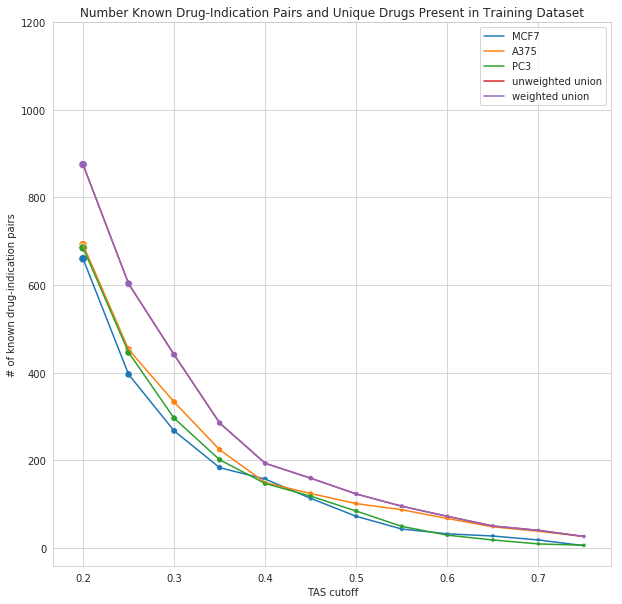

In [67]:
### set white grid
sns.set_style('whitegrid')
### create a figure with specified sizes
fig, ax = plt.subplots(figsize=(10,10))
### store the names of models
models=['MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']

### for each model
for model in models:
    ## define the marker size as the # of true drug-indication pairs
    num_drugs = train_num_drugs[model].astype(int).values
    sns.scatterplot(x=train_num_true['TAS cutoff'], y=train_num_true[model], size=num_drugs,legend=False)
    sns.lineplot(x=train_num_true['TAS cutoff'], y=train_num_true[model], label=model)

### add labels, title, legend
ax.set_xlabel('TAS cutoff')
ax.set_ylabel('# of known drug-indication pairs')
ax.set_title('Number Known Drug-Indication Pairs and Unique Drugs Present in Training Dataset')
ax.set_ylim(ymax=1200)
ax.legend()
plt.show()

#### *b. External validation (clin)*

In [68]:
# get the number of drugs and number of true drug-indication pairs available at each tas cutoff for validation data
val_num_drugs, val_num_true = compare_datasets(all_val_pred)
val_num_drugs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,380.0,372.0,364.0,523.0,523.0
1,0.25,261.0,267.0,262.0,399.0,399.0
2,0.30,191.0,206.0,192.0,307.0,307.0
3,0.35,140.0,156.0,151.0,225.0,225.0
4,0.40,115.0,119.0,122.0,178.0,178.0
5,0.45,96.0,101.0,90.0,143.0,143.0
6,0.50,72.0,90.0,67.0,119.0,119.0
7,0.55,55.0,80.0,53.0,99.0,99.0
8,0.60,39.0,66.0,38.0,80.0,80.0
9,0.65,29.0,47.0,25.0,58.0,58.0


In [69]:
val_num_true

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,14939.0,15540.0,15397.0,19250.0,19250.0
1,0.25,11113.0,12015.0,11439.0,14489.0,14489.0
2,0.30,8172.0,9897.0,9115.0,11891.0,11891.0
3,0.35,7108.0,8312.0,7578.0,9937.0,9937.0
4,0.40,6208.0,6349.0,6376.0,7840.0,7840.0
5,0.45,5499.0,5722.0,5127.0,6899.0,6899.0
6,0.50,3520.0,5358.0,3750.0,5973.0,5973.0
7,0.55,2273.0,4918.0,3022.0,5333.0,5333.0
8,0.60,1742.0,4440.0,1969.0,4900.0,4900.0
9,0.65,1339.0,3039.0,1493.0,3478.0,3478.0


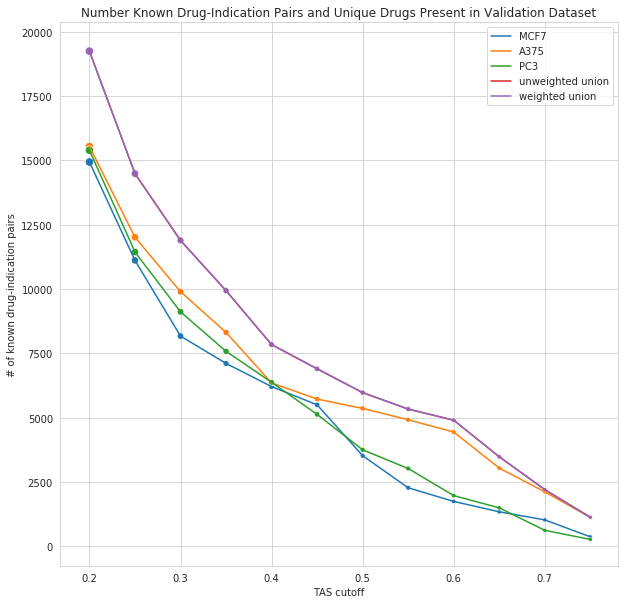

In [76]:
### create a figure with specified sizes
fig, ax = plt.subplots(figsize=(10,10))
models=['MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']

### for each model
for model in models:
    ## define the marker size as the # of true drug-indication pairs
    num_drugs = val_num_drugs[model].astype(int).values
    sns.scatterplot(x=val_num_true['TAS cutoff'], y=val_num_true[model], size=num_drugs,legend=False)
    sns.lineplot(x=val_num_true['TAS cutoff'], y=val_num_true[model], label=model)

### add labels, title, legend
ax.set_xlabel('TAS cutoff')
ax.set_ylabel('# of known drug-indication pairs')
ax.set_title('Number Known Drug-Indication Pairs and Unique Drugs Present in Validation Dataset')
#ax.set_ylim(ymax=1200)
ax.legend()
plt.show()

#### *c. Intersection between training and external validation datasets*

In [77]:
### function to get the intersection dataset for all model at a tas cutoff
def shared_dataset(train_pred, val_pred, model):
    ## initialize an empty dictionary to store the intersection datasets for all models at tas cutoff
    model_intersection_pred = {}
    ## for each model,
    for tas_cutoff in tas_cutoffs:
        # store the relevant data from the training dataset for that model
        train_data = train_pred[model][tas_cutoff][['drug1', 'drug2 indication', 'model prediction probabilities']]
        # store the relevant data from the validation dataset for that model
        val_data = val_pred[model][tas_cutoff][['drug1', 'drug2 indication', 'known indication', 'model prediction probabilities']]
        # store the intersection dataset
        intersection_data = pd.merge(train_data, val_data, on=['drug1', 'drug2 indication'], how='inner', suffixes=('_train', '_val'))
        # store the datasets for the model in the dictionary for all models
        model_intersection_pred[tas_cutoff] = intersection_data
    return model_intersection_pred

In [78]:
### initialize an empty dictionary to store the intersection datasets
all_intersection_pred = {}

### for each tas cutoff
for model in all_train_pred:
    ## store the intersection datasets between training and validation datasets at that tas cutoff
    tas_pred = shared_dataset(all_train_pred, all_val_pred, model)
    ## store the results to the dictionary for all tas cutoffs
    all_intersection_pred[model] = tas_pred
all_intersection_pred['unweighted union'][0.6].head()

,drug1,drug2 indication,model prediction probabilities_train,known indication,model prediction probabilities_val
0,ixazomib,Multiple Myeloma,0.829670,True,0.871416
1,metronidazole,Multiple Myeloma,0.864057,False,0.790447
2,ixazomib,"Lymphoma, Mantle-Cell",0.803984,True,0.641109
3,podophyllotoxin,Hypertension,0.813779,False,0.333791
4,thioguanine,"Leukemia, Myeloid, Acute",0.857708,True,0.696317


In [79]:
# store the number of drugs and known drug indication pairs in intersection datasets
shared_num_drugs, shared_num_true = compare_datasets(all_intersection_pred)
shared_num_drugs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,268.0,269.0,260.0,382.0,382.0
1,0.25,179.0,189.0,175.0,290.0,290.0
2,0.30,124.0,138.0,125.0,215.0,215.0
3,0.35,88.0,103.0,98.0,153.0,153.0
4,0.40,73.0,77.0,76.0,116.0,116.0
5,0.45,60.0,64.0,60.0,91.0,91.0
6,0.50,44.0,55.0,45.0,76.0,76.0
7,0.55,32.0,50.0,33.0,62.0,62.0
8,0.60,22.0,42.0,19.0,50.0,50.0
9,0.65,16.0,31.0,12.0,37.0,37.0


In [80]:
shared_num_true

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,2768.0,3003.0,2942.0,3932.0,3932.0
1,0.25,1905.0,2061.0,1921.0,2706.0,2706.0
2,0.30,1219.0,1548.0,1413.0,2020.0,2020.0
3,0.35,960.0,1194.0,1056.0,1528.0,1528.0
4,0.40,794.0,844.0,784.0,1091.0,1091.0
5,0.45,699.0,748.0,660.0,982.0,982.0
6,0.50,429.0,658.0,463.0,785.0,785.0
7,0.55,220.0,603.0,336.0,670.0,670.0
8,0.60,146.0,484.0,171.0,545.0,545.0
9,0.65,110.0,326.0,116.0,359.0,359.0


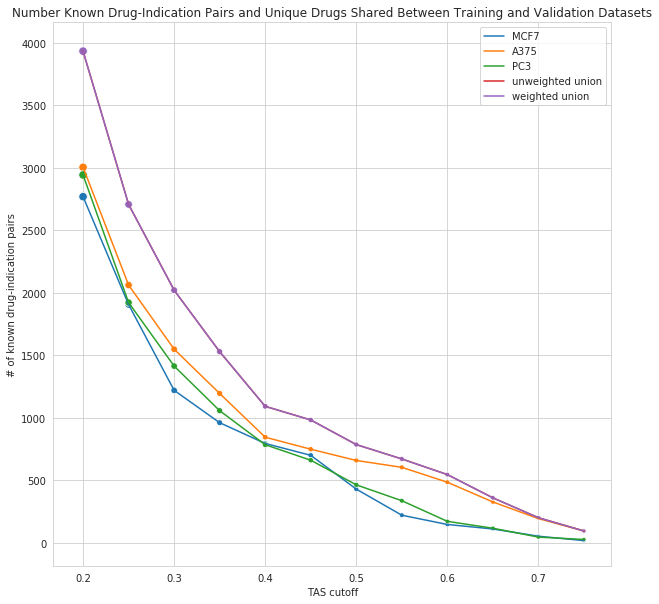

In [82]:
### create a figure with specified sizes
fig, ax = plt.subplots(figsize=(10,10))
models=['MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']

### for each model
for model in models:
    ## define the marker size as the # of true drug-indication pairs
    num_drugs = shared_num_drugs[model].astype(int).values
    sns.scatterplot(x=shared_num_true['TAS cutoff'], y=shared_num_true[model], size=num_drugs,legend=False)
    sns.lineplot(x=shared_num_true['TAS cutoff'], y=shared_num_true[model], label=model)

### add labels, title, legend
ax.set_xlabel('TAS cutoff')
ax.set_ylabel('# of known drug-indication pairs')
ax.set_title('Number Known Drug-Indication Pairs and Unique Drugs Shared Between Training and Validation Datasets')
#ax.set_ylim(ymax=1200)
ax.legend()
plt.show()

## Comparing AUCs

#### *a. Intersection datasets*

In [83]:
### function to compare aucs for intersection datasets
def intersection_aucs(intersection_pred, tas_cutoff):
    ## initialize a dictionary to store the AUCs
    train_aucs = {}
    val_aucs = {}
    
    ## for each model,
    for model in intersection_pred:
        # store all the predictions at that tas cutoff
        intersection_data = intersection_pred[model][tas_cutoff]
        # store the predictions probabilities
        train_pred = intersection_data['model prediction probabilities_train']
        val_pred = intersection_data['model prediction probabilities_val']
        # store the actual results (based on clinical indication dataset)
        known_ind = intersection_data['known indication'].astype(int)
        # store the AUC score
        tas_train_auc = roc_auc_score(known_ind, train_pred)
        tas_val_auc = roc_auc_score(known_ind, val_pred)
        # add the auc in the dictionary for that model as the key
        train_aucs[model] = tas_train_auc
        val_aucs[model] = tas_val_auc
        
    return train_aucs, val_aucs

In [84]:
### initialize an empty dataframe to store the aucs for intersection dataset across all tas cutoffs
columns = ['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']
intersection_train_aucs = pd.DataFrame(columns=columns)
intersection_val_aucs = pd.DataFrame(columns=columns)

### for each tas cutoff,
for tas_cutoff in tas_cutoffs:
    ## get the aucs for each model when analysis is performed with that tas cutoff
    tas_train_aucs, tas_val_aucs = intersection_aucs(all_intersection_pred, tas_cutoff)
    
    ## add this to the summary table
    intersection_train_aucs = intersection_train_aucs.append(tas_train_aucs, ignore_index=True)
    intersection_val_aucs = intersection_val_aucs.append(tas_val_aucs, ignore_index=True)

### add a column with the tas cutoffs to both dataframes
intersection_train_aucs['TAS cutoff'] = tas_cutoffs
intersection_val_aucs['TAS cutoff'] = tas_cutoffs

intersection_train_aucs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,0.566899,0.590815,0.581098,0.583738,0.584471
1,0.25,0.585877,0.606664,0.566412,0.580310,0.582856
2,0.30,0.564404,0.616350,0.578055,0.591287,0.590632
3,0.35,0.611285,0.641522,0.592140,0.614645,0.616146
4,0.40,0.584579,0.639607,0.618260,0.618769,0.618809
5,0.45,0.595346,0.648252,0.591160,0.614230,0.617513
6,0.50,0.598497,0.659692,0.597362,0.635045,0.635483
7,0.55,0.578861,0.666198,0.631635,0.650158,0.649717
8,0.60,0.535549,0.619241,0.599079,0.609494,0.600289
9,0.65,0.578644,0.593022,0.552759,0.581984,0.576021


In [85]:
intersection_val_aucs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,0.698440,0.716286,0.699477,0.724836,0.726001
1,0.25,0.705458,0.723492,0.696819,0.721915,0.725736
2,0.30,0.701849,0.738895,0.707198,0.723317,0.728343
3,0.35,0.736509,0.782756,0.714584,0.770694,0.776242
4,0.40,0.721815,0.771705,0.725128,0.770196,0.773290
5,0.45,0.725270,0.765656,0.708106,0.765516,0.766712
6,0.50,0.659220,0.763191,0.742414,0.765433,0.759746
7,0.55,0.668164,0.779902,0.713033,0.772394,0.771753
8,0.60,0.637689,0.760766,0.664289,0.748384,0.729645
9,0.65,0.623511,0.737489,0.717172,0.722426,0.717101


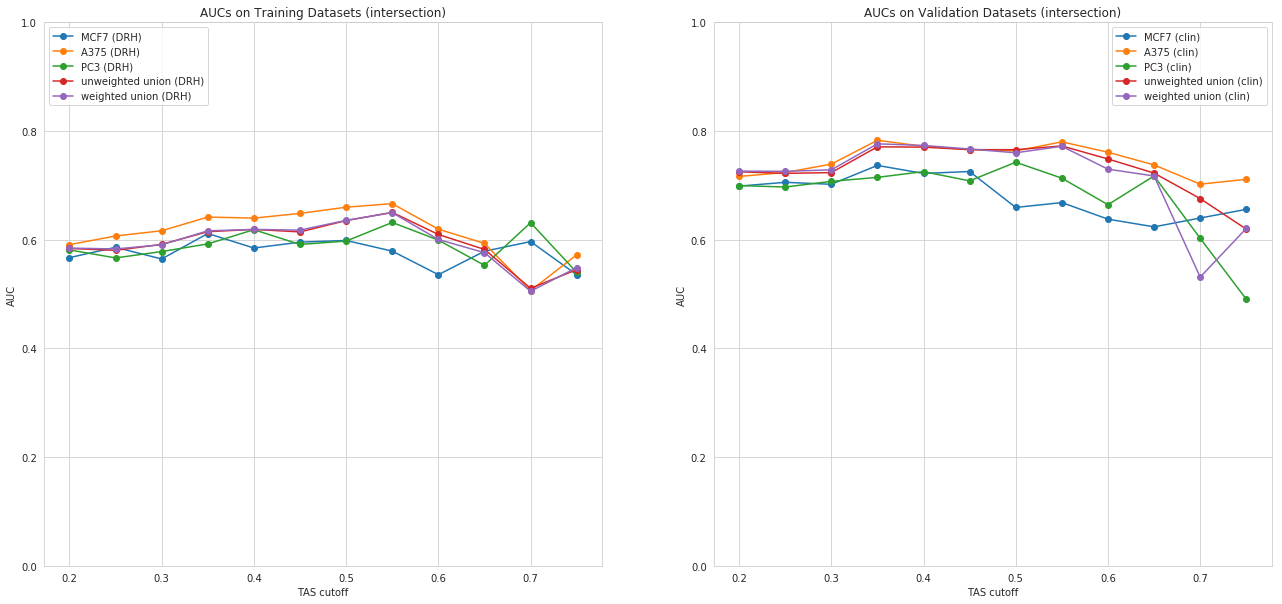

In [91]:
### create a new figure with 2 subplots side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22,10))
### for each model,
for model in models:
    ## show the AUC curves of training dataset on the left subplot
    axes[0].plot(intersection_train_aucs['TAS cutoff'], intersection_train_aucs[model], marker='o', label=model+' (DRH)')
    axes[1].plot(intersection_val_aucs['TAS cutoff'], intersection_val_aucs[model], marker='o', label=model+' (clin)')

### standardize y axis limits for comparison
axes[0].set_ylim(ymin=0, ymax=1)
axes[1].set_ylim(ymin=0, ymax=1)

### add legends
axes[0].legend(loc='upper left')
axes[1].legend()

### label x axis
axes[0].set_xlabel('TAS cutoff')
axes[1].set_xlabel('TAS cutoff')
### label y axis
axes[0].set_ylabel('AUC')
axes[1].set_ylabel('AUC')

### add title
axes[0].set_title('AUCs on Training Datasets (intersection)')
axes[1].set_title('AUCs on Validation Datasets (intersection)')

plt.show()

#### *b. All of training and validation datasets*

In [87]:
### function to obtain one ROC plot with ROC curves for all TAS thresholds
def auc_scores(all_predictions, tas_cutoff):
    ## initialize a dictionary to store the AUCs
    aucs = {}
    
    ## for each model,
    for model in all_predictions:
        # store all the predictions at that tas cutoff
        model_data = all_predictions[model][tas_cutoff]
        # store the predictions probabilities
        model_pred = model_data['model prediction probabilities']
        # store the actual results (based on clinical indication dataset)
        known_ind = model_data['known indication'].astype(int)
        # store the AUC score
        auc = roc_auc_score(known_ind, model_pred)
        # add the auc in the dictionary for that model as the key
        aucs[model] = auc
        
    return aucs

In [88]:
### intialize an empty list to store summary table of all auc scores for each cell at each tas cutoff
columns = ['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']
train_aucs = pd.DataFrame(columns=columns)
val_aucs = pd.DataFrame(columns=columns)

### for each tas cutoff,
for tas_cutoff in tas_cutoffs:
    ## get the aucs for each model when analysis is performed with that tas cutoff
    tas_train_aucs = auc_scores(all_train_pred, tas_cutoff)
    tas_val_aucs = auc_scores(all_val_pred, tas_cutoff)
    
    ## add this to the summary table
    train_aucs = train_aucs.append(tas_train_aucs, ignore_index=True)
    val_aucs = val_aucs.append(tas_val_aucs, ignore_index=True)

### add a column with the tas cutoffs to both dataframes
train_aucs['TAS cutoff'] = tas_cutoffs
val_aucs['TAS cutoff'] = tas_cutoffs

train_aucs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,0.695370,0.719546,0.693436,0.716950,0.715944
1,0.25,0.690156,0.734597,0.692906,0.716296,0.715061
2,0.30,0.691501,0.739904,0.665170,0.703566,0.702599
3,0.35,0.739951,0.713756,0.685028,0.716811,0.716423
4,0.40,0.730186,0.713867,0.725452,0.728054,0.729746
5,0.45,0.794401,0.736128,0.743933,0.745024,0.744917
6,0.50,0.799295,0.763163,0.767893,0.777249,0.770443
7,0.55,0.739167,0.781067,0.796199,0.782415,0.780660
8,0.60,0.791056,0.746162,0.705518,0.734315,0.734374
9,0.65,0.790547,0.787283,0.701502,0.785836,0.792273


In [89]:
val_aucs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,0.746070,0.758338,0.749094,0.770109,0.769722
1,0.25,0.758638,0.755198,0.739646,0.760272,0.761961
2,0.30,0.750703,0.761229,0.746052,0.763014,0.763245
3,0.35,0.768586,0.775541,0.744603,0.783628,0.786120
4,0.40,0.762175,0.773672,0.731013,0.775649,0.779428
5,0.45,0.767488,0.774103,0.722598,0.769660,0.772087
6,0.50,0.724568,0.766511,0.721364,0.766514,0.766500
7,0.55,0.690500,0.778581,0.688720,0.758309,0.760983
8,0.60,0.666806,0.757633,0.668157,0.742965,0.725237
9,0.65,0.655073,0.733247,0.675344,0.712878,0.697145


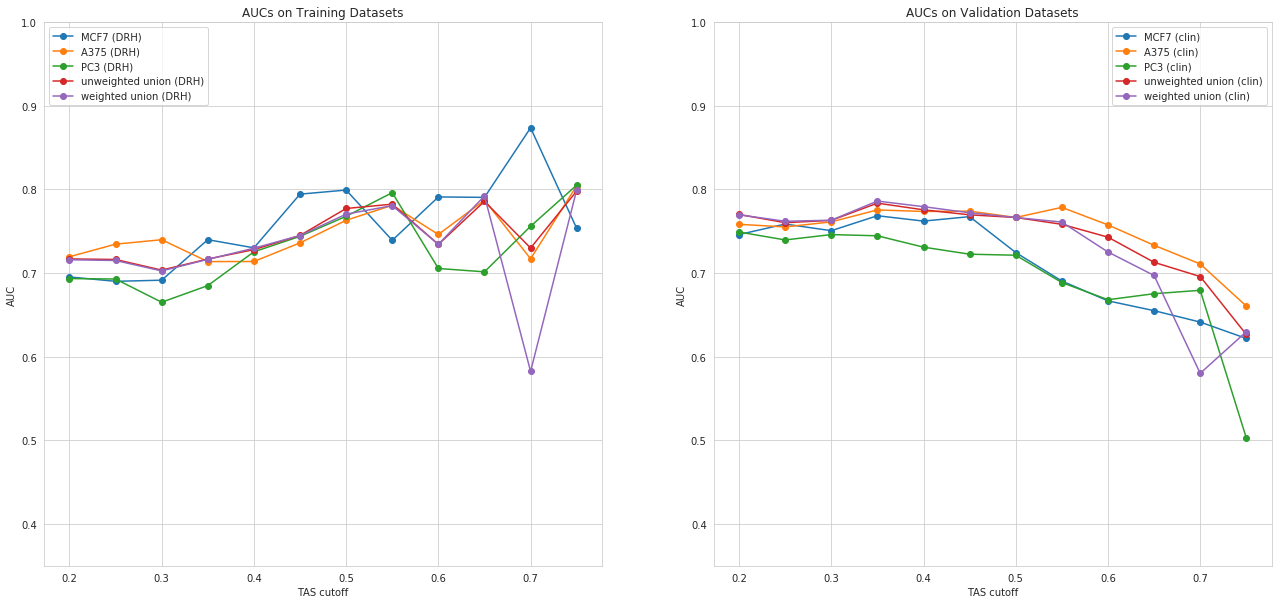

In [90]:
### create a new figure with 2 subplots side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22,10))
### for each model,
for model in models:
    ## show the AUC curves of training dataset on the left subplot
    axes[0].plot(train_aucs['TAS cutoff'], train_aucs[model], marker='o', label=model+' (DRH)')
    axes[1].plot(train_aucs['TAS cutoff'], val_aucs[model], marker='o', label=model+' (clin)')

### standardize y axis limits for comparison
axes[0].set_ylim(ymin=0.35, ymax=1)
axes[1].set_ylim(ymin=0.35, ymax=1)

### add legends
axes[0].legend(loc='upper left')
axes[1].legend()

### label x axis
axes[0].set_xlabel('TAS cutoff')
axes[1].set_xlabel('TAS cutoff')
### label y axis
axes[0].set_ylabel('AUC')
axes[1].set_ylabel('AUC')

### add title
axes[0].set_title('AUCs on Training Datasets')
axes[1].set_title('AUCs on Validation Datasets')

plt.show()

#### *c. Validation Dataset (removing shared drug-indication pairs)*

In [ ]:
### function to get validation datasets containing only the unseen data for all models at that tas cutoff
def gen_unseen_val(all_intersection_pred, all_val_pred, model):
    ## initialize a dataframe to store the validation dataset containing only unseen data
    unseen_val_pred = {}
    
    ## for each tas cutoff
    for tas_cutoff in tas_cutoffs:
        # store the shared drug-indication pairs for that model at that tas cutoff
        shared_pairs = all_intersection_pred[model][tas_cutoff].drop(columns=['known indication', 'model prediction probabilities_val'], axis=1)
        # store the validation dataset for that model at that tas cutoff
        val_pred = all_val_pred[model][tas_cutoff]
        # combine the intersection 
        all_pred = pd.merge(val_pred, shared_pairs, on=['drug1', 'drug2 indication'], how='left')
        # remove drug-indication pairs present in training dataset
        unseen_pred = all_pred[all_pred['model prediction probabilities_train'].isna()].drop('model prediction probabilities_train', axis=1)
        # store the unseen validation dataset in that dictionary for that model
        unseen_val_pred[tas_cutoff] = unseen_pred
        
    return unseen_val_pred

In [ ]:
### initialize a dictionary to store the unseen validation datasets across all tas cutoffs
all_unseen_val_pred = {}
### for each tas cutoff
for model in all_val_pred:
    ## store the unseen validation datasets for all models at that tas cutoff
    unseen_val_pred = gen_unseen_val(all_intersection_pred, all_val_pred, model)
    ## add the validation datasets to dictionary for that tas cutoff
    all_unseen_val_pred[model] = unseen_val_pred

all_unseen_val_pred['MCF7'][0.6].head()

In [ ]:
### intialize an empty dataframe to store of all auc scores across all tas cutoffs for unseen validation datasets
columns = ['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']
unseen_val_aucs = pd.DataFrame(columns=columns)

### removing 0.7 and 0.75 from analysis because no known drug-indication pairs
val_tas_cutoffs = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]

### for each tas cutoff,
for tas_cutoff in val_tas_cutoffs:
    ## get the aucs for each model when analysis is performed with that tas cutoff
    tas_val_aucs = auc_scores(all_unseen_val_pred, tas_cutoff)
    
    ## add this to the summary table
    unseen_val_aucs = unseen_val_aucs.append(tas_val_aucs, ignore_index=True)

### add a column with the tas cutoffs to both dataframes
unseen_val_aucs['TAS cutoff'] = val_tas_cutoffs

unseen_val_aucs

In [ ]:
### create a new figure with 2 subplots side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22,10))
### for each model,
for model in models:
    ## show the AUC curves of training dataset on the left subplot
    axes[0].plot(train_aucs['TAS cutoff'].iloc[:-2], train_aucs[model].iloc[:-2], marker='o', label=model+' (DRH)')
    axes[1].plot(unseen_val_aucs['TAS cutoff'], unseen_val_aucs[model], marker='o', label=model+' (clin)')

### standardize y axis limits for comparison
axes[0].set_ylim(ymin=0.2, ymax=1)
axes[1].set_ylim(ymin=0.2, ymax=1)

### add legends
axes[0].legend(loc='upper left')
axes[1].legend()

### label x axis
axes[0].set_xlabel('TAS cutoff')
axes[1].set_xlabel('TAS cutoff')
### label y axis
axes[0].set_ylabel('AUC')
axes[1].set_ylabel('AUC')

### add title
axes[0].set_title('AUCs on Training Datasets')
axes[1].set_title('AUCs on Validation Datasets (Unseen Data)')

plt.show()

## Comparing True Positive Rates

In [ ]:
### function to determine the true positive rates
def get_TPR(all_predictions, tas_cutoff):
    ## initialize an empty dictionary to store the true positive rates tas cutoff
    TPRs = {}
    ## for each model,
    for model in all_predictions:
        # store the data at that tas cutoff
        model_data = all_predictions[model][tas_cutoff]
        # store known drug-indication pairs dataset
        known_ind = model_data[model_data['known indication']]
        # store the true positive rate
        TPR = known_ind['model prediction probabilities'].sum()/float(len(known_ind)) * 100
        # store the true positive rate for that model in dictionary
        TPRs[model] = TPR
        
    return TPRs

In [ ]:
### initialize an empty dataframe to store all of the true positive rates for the training and validation datasets
train_TPRs = pd.DataFrame(columns=['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union'])
val_TPRs = pd.DataFrame(columns=['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union'])

### for each tas cutoff
for tas_cutoff in tas_cutoffs:
    ## store the true positives rates for all models at that tas cutoff
    tas_train_tpr = get_TPR(all_train_pred, tas_cutoff)
    tas_val_tpr = get_TPR(all_val_pred, tas_cutoff)
    ## add the true positive rates to the dataframe
    train_TPRs = train_TPRs.append(tas_train_tpr, ignore_index=True)
    val_TPRs = val_TPRs.append(tas_val_tpr, ignore_index=True)
### add a column with the tas cutoffs
train_TPRs['TAS cutoff'] = tas_cutoffs
val_TPRs['TAS cutoff'] = tas_cutoffs
train_TPRs

In [ ]:
val_TPRs

In [ ]:
### create a new figure with 2 subplots side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22,10))
### for each model,
for model in models:
    ## show the AUC curves of training dataset on the left subplot
    axes[0].plot(train_TPRs['TAS cutoff'], train_TPRs[model], marker='o', label=model+' (DRH)')
    axes[1].plot(train_TPRs['TAS cutoff'], val_TPRs[model], marker='o', label=model+' (clin)')

### standardize y axis limits for comparison
axes[0].set_ylim(ymin=0, ymax=100)
axes[1].set_ylim(ymin=0, ymax=100)

### add legends
axes[0].legend(loc='upper left')
axes[1].legend()

### label x axis
axes[0].set_xlabel('TAS cutoff')
axes[1].set_xlabel('TAS cutoff')
### label y axis
axes[0].set_ylabel('Total Positive Rate (TPR)')
axes[1].set_ylabel('Total Positive Rate (TPR)')

### add title
axes[0].set_title('Total Positive Rates (TPRs) on Training Datasets')
axes[1].set_title('Total Positive Rates (TPRs) on Validation Datasets')
plt.show()